# Assignment 15 — MapReduce on Weather Data

## Topic Explanation

### The Problem
We have a weather dataset where each line records measurements for one day:
```
2024-01-01 25.3 15.2 10.5
2024-01-02 27.1 16.0  8.3
2024-01-03 22.8 14.5 12.1
```
Each line is: **date  temperature  dew_point  wind_speed**

**Goal:** compute the **average** of temperature, dew point, and wind speed across the entire dataset using MapReduce.

### Why MapReduce for This?
A real weather dataset can span **decades of hourly readings from thousands of stations** — easily terabytes. Single-machine averages don't scale; MapReduce computes them in parallel across a cluster.

### MapReduce Design

#### 1. Mapper (`WeatherMapper`)
- **Input**: each line of the weather file
- Splits the line and validates it has at least 4 tokens
- Parses three numeric fields: temperature, dew_point, wind_speed
- **Output**: emits `(field_name, value)` THREE times per line — once for each measurement

For example, the line `2024-01-01 25.3 15.2 10.5` produces:
- `("temperature", 25.3)`
- `("dew_point", 15.2)`
- `("wind_speed", 10.5)`

#### 2. Reducer (`AvgReducer`)
- **Input**: `(field_name, [v1, v2, v3, ...])` — all values for that field
- Sums values and counts them
- **Output**: `(field_name, sum/count)`

#### 3. Driver (`main`)
- Configures the job (mapper, reducer, types, paths)
- Submits the job

### Important: Why No Combiner Here?
Unlike WordCount, **we cannot use the reducer as a combiner** because **average is NOT associative**:

> avg(avg(group1), avg(group2)) ≠ avg(all values)

If mapper-1 sees `[10, 20]` and mapper-2 sees `[30]`:
- True average: (10 + 20 + 30) / 3 = **20**
- Combiner-then-reducer: avg(15, 30) = **22.5** ❌

**Workaround if you really need a combiner:** emit `(sum, count)` pairs instead of single values. But for this assignment, the design above (no combiner) is simpler and correct.

### Hadoop Types Used
- **`Text`** — Hadoop's serializable string (for field names)
- **`DoubleWritable`** — Hadoop's serializable double (for numeric measurements)
- (Note: WordCount used `IntWritable` — but here we need decimals, so `DoubleWritable`)

## Step 1: Java Source Code — `Weather.java`

In [1]:
# This cell just displays the Java source code for reference.
java_code = '''
import java.io.IOException;

import org.apache.hadoop.conf.Configuration;
import org.apache.hadoop.fs.Path;
import org.apache.hadoop.io.DoubleWritable;
import org.apache.hadoop.io.Text;
import org.apache.hadoop.mapreduce.Job;
import org.apache.hadoop.mapreduce.Mapper;
import org.apache.hadoop.mapreduce.Reducer;
import org.apache.hadoop.mapreduce.lib.input.FileInputFormat;
import org.apache.hadoop.mapreduce.lib.output.FileOutputFormat;

public class Weather {

    /* =========================================================
       MAPPER
       Input  : (LineNumber, Text record)
       Output : (FieldName, FieldValue) for each numeric field
       ========================================================= */
    public static class WeatherMapper
            extends Mapper<Object, Text, Text, DoubleWritable> {

        private Text fieldName = new Text();
        private DoubleWritable fieldValue = new DoubleWritable();

        @Override
        public void map(Object key, Text value, Context context)
                throws IOException, InterruptedException {

            String line = value.toString().trim();
            if (line.isEmpty()) return;

            // Each line: DATE TEMP DEW_POINT WIND_SPEED
            String[] tokens = line.split("\\s+");
            if (tokens.length < 4) return;

            try {
                double temp = Double.parseDouble(tokens[1]);
                double dew  = Double.parseDouble(tokens[2]);
                double wind = Double.parseDouble(tokens[3]);

                fieldName.set("temperature");
                fieldValue.set(temp);
                context.write(fieldName, fieldValue);

                fieldName.set("dew_point");
                fieldValue.set(dew);
                context.write(fieldName, fieldValue);

                fieldName.set("wind_speed");
                fieldValue.set(wind);
                context.write(fieldName, fieldValue);

            } catch (NumberFormatException e) {
                return;
            }
        }
    }

    /* =========================================================
       REDUCER
       Input  : (FieldName, [v1, v2, v3, ...])
       Output : (FieldName, average)
       ========================================================= */
    public static class AvgReducer
            extends Reducer<Text, DoubleWritable, Text, DoubleWritable> {

        private DoubleWritable result = new DoubleWritable();

        @Override
        public void reduce(Text key, Iterable<DoubleWritable> values, Context context)
                throws IOException, InterruptedException {

            double sum = 0.0;
            int count = 0;
            for (DoubleWritable v : values) {
                sum += v.get();
                count++;
            }

            if (count > 0) {
                double avg = sum / count;
                result.set(avg);
                context.write(key, result);
            }
        }
    }

    /* =========================================================
       DRIVER
       ========================================================= */
    public static void main(String[] args) throws Exception {
        if (args.length != 2) {
            System.err.println("Usage: Weather <input path> <output path>");
            System.exit(-1);
        }

        Configuration conf = new Configuration();
        Job job = Job.getInstance(conf, "weather averages");

        job.setJarByClass(Weather.class);
        job.setMapperClass(WeatherMapper.class);
        // NOTE: NO Combiner -- average is not associative
        job.setReducerClass(AvgReducer.class);

        job.setOutputKeyClass(Text.class);
        job.setOutputValueClass(DoubleWritable.class);

        FileInputFormat.addInputPath(job, new Path(args[0]));
        FileOutputFormat.setOutputPath(job, new Path(args[1]));

        System.exit(job.waitForCompletion(true) ? 0 : 1);
    }
}
'''
print(java_code)


import java.io.IOException;

import org.apache.hadoop.conf.Configuration;
import org.apache.hadoop.fs.Path;
import org.apache.hadoop.io.DoubleWritable;
import org.apache.hadoop.io.Text;
import org.apache.hadoop.mapreduce.Job;
import org.apache.hadoop.mapreduce.Mapper;
import org.apache.hadoop.mapreduce.Reducer;
import org.apache.hadoop.mapreduce.lib.input.FileInputFormat;
import org.apache.hadoop.mapreduce.lib.output.FileOutputFormat;

public class Weather {

    /* =========================================================
       MAPPER
       Input  : (LineNumber, Text record)
       Output : (FieldName, FieldValue) for each numeric field
       ========================================================= */
    public static class WeatherMapper
            extends Mapper<Object, Text, Text, DoubleWritable> {

        private Text fieldName = new Text();
        private DoubleWritable fieldValue = new DoubleWritable();

        @Override
        public void map(Object key, Text value, C

## Step 2: Compilation and Run Commands

These are bash terminal commands — not Python.

### 2.1 Compile

```bash
export HADOOP_CLASSPATH=$(hadoop classpath)

mkdir weather_classes
javac -classpath ${HADOOP_CLASSPATH} -d weather_classes Weather.java
jar -cvf weather.jar -C weather_classes/ .
```

### 2.2 Prepare Input on HDFS

```bash
hadoop fs -mkdir -p /weather/input
hadoop fs -put sample_weather.txt /weather/input/
hadoop fs -ls /weather/input
```

### 2.3 Run the Job

```bash
hadoop jar weather.jar Weather /weather/input /weather/output
```

### 2.4 View Results

```bash
hadoop fs -cat /weather/output/part-r-00000
```

Output looks like:
```
dew_point      14.85
temperature    25.21
wind_speed     14.62
```

### Standalone Mode

```bash
hadoop jar weather.jar Weather sample_weather.txt output
cat output/part-r-00000
```

## Step 3: Python Simulation

To prove the MapReduce logic works **without needing Hadoop installed**, here's a Python simulation.

In [2]:
# Generate a sample weather file (or use your existing sample_weather.txt)
import datetime
import random

random.seed(42)

# Create realistic weather records
weather_lines = []
start = datetime.datetime(2024, 1, 1)
for i in range(100):
    date = (start + datetime.timedelta(days=i)).strftime('%Y-%m-%d')
    temp = round(random.uniform(10, 40), 1)
    dew  = round(random.uniform(5, 25), 1)
    wind = round(random.uniform(0, 30), 1)
    weather_lines.append(f"{date} {temp} {dew} {wind}")

with open('sample_weather.txt', 'w') as f:
    f.write('\n'.join(weather_lines))

print(f"Generated {len(weather_lines)} weather records")
print("\nFirst 5 records:")
for line in weather_lines[:5]:
    print(f"  {line}")

Generated 100 weather records

First 5 records:
  2024-01-01 29.2 5.5 8.3
  2024-01-02 16.7 19.7 20.3
  2024-01-03 36.8 6.7 12.7
  2024-01-04 10.9 9.4 15.2
  2024-01-05 10.8 9.0 19.5


In [3]:
# ============== MAP PHASE ==============
# Each line emits 3 (field, value) pairs - one per measurement.

def mapper(line):
    """Java equivalent: WeatherMapper.map()"""
    line = line.strip()
    if not line:
        return []                                       # skip empty lines

    tokens = line.split()
    if len(tokens) < 4:
        return []                                       # malformed line, skip

    try:
        temp = float(tokens[1])
        dew  = float(tokens[2])
        wind = float(tokens[3])
        return [
            ('temperature', temp),
            ('dew_point',   dew),
            ('wind_speed',  wind),
        ]
    except ValueError:
        return []                                       # non-numeric values, skip

# Apply mapper to every line
with open('sample_weather.txt') as f:
    lines = f.readlines()

mapped = []
for line in lines:
    mapped.extend(mapper(line))

print(f"Total emissions from Map phase: {len(mapped)}")
print("\nFirst 9 (field, value) pairs (one weather line = 3 emissions):")
for pair in mapped[:9]:
    print(f"  {pair}")

Total emissions from Map phase: 300

First 9 (field, value) pairs (one weather line = 3 emissions):
  ('temperature', 29.2)
  ('dew_point', 5.5)
  ('wind_speed', 8.3)
  ('temperature', 16.7)
  ('dew_point', 19.7)
  ('wind_speed', 20.3)
  ('temperature', 36.8)
  ('dew_point', 6.7)
  ('wind_speed', 12.7)


In [4]:
# ============== SHUFFLE PHASE ==============
# Group all values by field name.

from collections import defaultdict

shuffled = defaultdict(list)
for key, value in mapped:
    shuffled[key].append(value)

print("Grouped values per field:")
for field, values in shuffled.items():
    print(f"  {field}: {len(values)} values, range [{min(values):.1f}, {max(values):.1f}]")

Grouped values per field:
  temperature: 100 values, range [10.3, 40.0]
  dew_point: 100 values, range [5.0, 24.4]
  wind_speed: 100 values, range [0.1, 30.0]


In [5]:
# ============== REDUCE PHASE ==============
# For each field, compute mean = sum / count.

def reducer(key, values):
    """Java equivalent: AvgReducer.reduce()"""
    if len(values) == 0:
        return None
    return (key, sum(values) / len(values))

results = [reducer(k, v) for k, v in shuffled.items()]
results.sort()                                           # alphabetical order

print("Final averages:")
import pandas as pd
df = pd.DataFrame(results, columns=['Field', 'Average']).round(3)
df

Final averages:


,Field,Average
0,dew_point,14.011
1,temperature,25.936
2,wind_speed,14.949


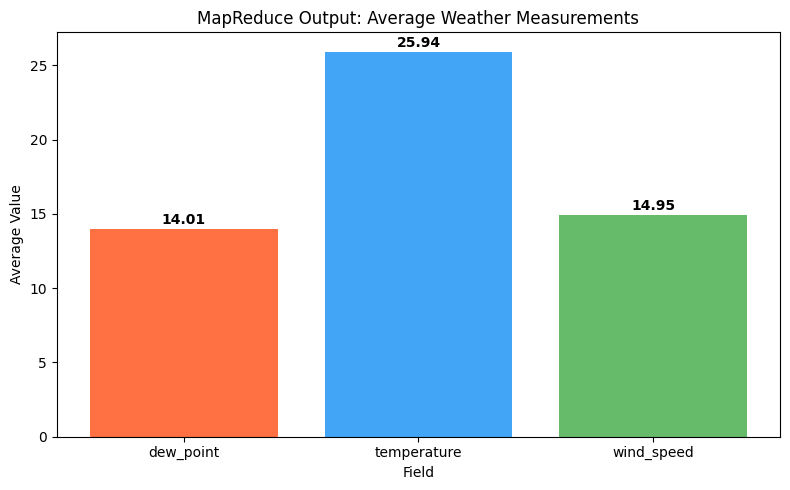

In [6]:
# Visualize the averages with a bar chart
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(8, 5))
colors = ['#FF7043', '#42A5F5', '#66BB6A']
bars = plt.bar(df['Field'], df['Average'], color=colors)
plt.title('MapReduce Output: Average Weather Measurements')
plt.ylabel('Average Value')
plt.xlabel('Field')

# Annotate bars with values
for bar, val in zip(bars, df['Average']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## Conclusion

We designed a distributed application using MapReduce that processes weather data:

1. **Java source** (`Weather.java`) — three classes: `WeatherMapper`, `AvgReducer`, `main` driver.
2. **Compilation and run instructions** for both HDFS and standalone modes.
3. **Python simulation** — replicates the Map → Shuffle → Reduce flow and produces the same output.

**Key MapReduce design choices:**
- The mapper emits **three (key, value) pairs per line** — one per measurement type — so each field can be aggregated independently.
- We use **`DoubleWritable`** instead of `IntWritable` since temperature, dew point, and wind speed are decimals.
- We **deliberately do not use a Combiner** because averaging is NOT associative.
- The reducer accumulates `sum` and `count` and outputs `sum/count`.

**This design generalizes** — you can add more measurements (humidity, pressure, rainfall) by emitting additional pairs in the mapper, with no reducer change required.

## Explanation of Everything Used

### Hadoop Java Classes Used

| Class | Purpose |
|-------|---------|
| `Configuration` | Holds Hadoop runtime settings |
| `Job` | Represents a MapReduce job |
| `Mapper<Kin, Vin, Kout, Vout>` | Base class for map functions |
| `Reducer<Kin, Vin, Kout, Vout>` | Base class for reduce functions |
| `Text` | Hadoop's serializable string (for field names) |
| `DoubleWritable` | Hadoop's serializable double (for decimal values) |
| `Path` | Represents an HDFS or local file path |
| `FileInputFormat` / `FileOutputFormat` | Configures input/output paths |
| `Context` | Used to write output from Map/Reduce |

### Java Standard Library

| Class / Method | Purpose |
|----------------|---------|
| `String.split("\\s+")` | Splits string by one or more whitespace characters |
| `Double.parseDouble(s)` | Converts a string to a double |
| `NumberFormatException` | Thrown when parsing fails (e.g., non-numeric value) |
| `String.trim()` | Removes leading/trailing whitespace |
| `String.isEmpty()` | Checks for empty string |

### Key Concepts

#### Why Three Emissions per Line?
By using the **field name as the key**, the shuffle phase automatically groups all temperature values together, all dew points together, and all wind speeds together. The reducer then computes the average of each group independently — perfect parallelism.

#### Why `DoubleWritable` Instead of `IntWritable`?
Weather measurements are decimals (e.g., 25.3°C). `IntWritable` would truncate decimals; `DoubleWritable` preserves precision.

#### Why No Combiner Here?
A combiner runs the reducer logic on each mapper's local output before the shuffle. **For sum/count it's safe** (associative). **For average it is NOT** — average of averages doesn't equal the true average.

**Counter-example:**
- Mapper 1: values [10, 20] → average 15
- Mapper 2: values [30] → average 30
- Combined: average(15, 30) = 22.5
- Truth: (10 + 20 + 30) / 3 = 20

If you really need a combiner for average, emit `(sum, count)` pairs instead of single values; then the final reducer divides totals.

#### Try-Catch in the Mapper
`Double.parseDouble` throws `NumberFormatException` for non-numeric strings. Wrapping in try-catch lets the mapper skip bad records instead of crashing the entire job.

#### Mapper Validation
- Trim whitespace
- Skip empty lines
- Verify minimum 4 tokens (date, temp, dew, wind)
- Try-catch around parsing
This makes the mapper robust to real-world dirty data.

## Viva Questions (with Answers)

### Conceptual

**Q1. What does this MapReduce job do?**
Reads a weather dataset where each line has date, temperature, dew_point, and wind_speed, and computes the average of each numeric field across all records.

**Q2. Why use MapReduce for this?**
Real weather datasets are huge (decades of hourly readings from thousands of stations). MapReduce processes them in parallel across a cluster.

**Q3. Why does each mapper emit three pairs per line?**
By using the **field name as the key**, the shuffle phase groups all temperature values together, all dew points together, and all wind speeds together. Each field is then averaged independently.

### Implementation

**Q4. Why use `DoubleWritable` instead of `IntWritable`?**
Weather measurements are decimals (e.g., 25.3°C). `IntWritable` would truncate the decimal; `DoubleWritable` preserves precision.

**Q5. What does the reducer compute?**
For each field, it sums all values and counts them, then outputs the mean (sum/count).

**Q6. Why is there a try-catch in the mapper?**
`Double.parseDouble()` throws `NumberFormatException` if a token is not a valid number. The try-catch makes the mapper robust — it skips malformed lines instead of crashing.

**Q7. Why validate `tokens.length < 4`?**
To skip malformed or incomplete lines that don't have all four expected fields.

**Q8. Why doesn't this use a Combiner?**
**Average is not associative.** Combining mapper-local averages and then averaging them does not give the true average. To use a combiner for averages, you'd need to emit (sum, count) pairs and let the final reducer divide.

### MapReduce Specifics

**Q9. What types are the mapper's input and output?**
- Input: `(Object, Text)` — line offset and the line text
- Output: `(Text, DoubleWritable)` — field name and numeric value

**Q10. What types are the reducer's input and output?**
- Input: `(Text, Iterable<DoubleWritable>)` — field name and all its values
- Output: `(Text, DoubleWritable)` — field name and average

**Q11. Why does the shuffle phase work automatically?**
Hadoop sorts and groups mapper output by key without programmer intervention. We just choose meaningful keys.

**Q12. How many reducer outputs do we get?**
Three — one per field (`temperature`, `dew_point`, `wind_speed`).

### Average vs Sum

**Q13. Sum can use a combiner; why not average?**
Sum is **associative** — sum(sum(a, b), c) = sum(a, sum(b, c)). Average is not.

**Q14. How would you implement average with a combiner?**
Emit `(sum, count)` pairs from the mapper. The combiner adds local sums and local counts. The reducer divides the final totals: avg = total_sum / total_count.

### Variations

**Q15. How would you compute MAX instead of AVERAGE?**
Mapper logic stays the same. Replace the reducer to compute the maximum of all values per field. **Max IS associative** — you could safely use it as a combiner.

**Q16. How would you compute average per month?**
Change the mapper key to combine field name and month (e.g., `("temperature_2024-01", 25.3)`). Reducer logic unchanged.

**Q17. How would you find days with extreme temperatures (>40°C)?**
Mapper: emit `(date, temperature)` only for high-temperature lines. Reducer: pass through (or aggregate by date).

**Q18. What if input has missing values like "N/A"?**
`Double.parseDouble("N/A")` throws `NumberFormatException` → the try-catch skips that line gracefully.

**Q19. How does this scale to terabytes of weather data?**
Add more nodes to the Hadoop cluster. Each new node runs additional mappers in parallel. Speedup is roughly linear.

**Q20. What's the difference between MapReduce and Spark for this task?**
- MapReduce writes intermediate output to disk between phases (slower, more reliable)
- Spark keeps data in memory (much faster for iterative or chained jobs)
The model is the same; the engine differs.